In [64]:
import pandas as pd
import glob
import os

# 1. 獲取該資料夾下所有 CSV 檔案的路徑
file_paths = glob.glob('*.csv')  

# 2. 建立一個字典來存放所有 DataFrame
All_Data = {}

for path in file_paths:
    # 取得檔案名稱（不含路徑與副檔名），例如 "大同_2019"
    file_name = os.path.splitext(os.path.basename(path))[0]
    
    # 讀取檔案，並處理編碼問題（環保署資料常用 utf-8 或 cp950）
    df = pd.read_csv(path, encoding='utf-8')
    
    # 將處理後的結果存入字典
    All_Data[file_name] = df
    print(f"已成功讀取檔案: {file_name}")

已成功讀取檔案: 富貴角_2020
已成功讀取檔案: 桃園_2019
已成功讀取檔案: 基隆_2021
已成功讀取檔案: 新莊_2018
已成功讀取檔案: 板橋_2023
已成功讀取檔案: 土城_2020
已成功讀取檔案: 土城_2021
已成功讀取檔案: 板橋_2022
已成功讀取檔案: 新莊_2019
已成功讀取檔案: 基隆_2020
已成功讀取檔案: 桃園_2018
已成功讀取檔案: 富貴角_2021
已成功讀取檔案: 富貴角_2023
已成功讀取檔案: 中壢_2019
已成功讀取檔案: 基隆_2022
已成功讀取檔案: 板橋_2020
已成功讀取檔案: 土城_2023
已成功讀取檔案: 土城_2022
已成功讀取檔案: 板橋_2021
已成功讀取檔案: 基隆_2023
已成功讀取檔案: 中壢_2018
已成功讀取檔案: 富貴角_2022
已成功讀取檔案: 桃園_2023
已成功讀取檔案: 中壢_2020
已成功讀取檔案: 新莊_2022
已成功讀取檔案: 板橋_2019
已成功讀取檔案: 板橋_2018
已成功讀取檔案: 新莊_2023
已成功讀取檔案: 中壢_2021
已成功讀取檔案: 桃園_2022
已成功讀取檔案: 富貴角_2019
已成功讀取檔案: 桃園_2020
已成功讀取檔案: 中壢_2023
已成功讀取檔案: 基隆_2018
已成功讀取檔案: 新莊_2021
已成功讀取檔案: 土城_2019
已成功讀取檔案: 土城_2018
已成功讀取檔案: 新莊_2020
已成功讀取檔案: 基隆_2019
已成功讀取檔案: 中壢_2022
已成功讀取檔案: 桃園_2021
已成功讀取檔案: 富貴角_2018
已成功讀取檔案: 林口_2022
已成功讀取檔案: 萬里_2020
已成功讀取檔案: 中山_2019
已成功讀取檔案: 中山_2018
已成功讀取檔案: 萬里_2021
已成功讀取檔案: 林口_2023
已成功讀取檔案: 林口_2021
已成功讀取檔案: 觀音_2018
已成功讀取檔案: 萬里_2023
已成功讀取檔案: 士林_2019
已成功讀取檔案: 士林_2018
已成功讀取檔案: 萬里_2022
已成功讀取檔案: 觀音_2019
已成功讀取檔案: 林口_2020
已成功讀取檔案: 林口_2018
已成功讀取檔案: 觀音_2021
已成功讀取檔案:

In [65]:
def transform_air_data(df):
    # 將環保署橫向格式轉為縱向時間序列
    # 1. 將 00-23 欄位轉為一列
    hour_cols = [f'{i:02d}' for i in range(24)]
    df_long = df.melt(id_vars=['測站', '日期', '測項'], 
                      value_vars=hour_cols,
                      var_name='小時', value_name='濃度')
    
    # 2. 處理時間與數值轉換
    df_long['時間'] = pd.to_datetime(df_long['日期']) + pd.to_timedelta(df_long['小時'].astype(int), unit='h')
    df_long['濃度'] = pd.to_numeric(df_long['濃度'], errors='coerce') # 符號變 NaN
    
    # 3. 轉置測項 (樞紐分析)
    df_pivot = df_long.pivot_table(index='時間', columns='測項', values='濃度')
    return df_pivot.sort_index()

# 批量應用轉換
cleaned_dfs = {name: transform_air_data(df) for name, df in All_Data.items()}

In [80]:
# 建立一個字典來存放合併後的各測站 DataFrame
Station_Merged = {}

for file_key, df in cleaned_dfs.items():
    # 假設 file_key 格式為 "大同_2019"，我們取底線前的部分作為測站名
    station_name = file_key.split('_')[0]
    
    if station_name not in Station_Merged:
        Station_Merged[station_name] = []
    
    Station_Merged[station_name].append(df)

# 將每個測站的清單進行 concat 合併
for station in Station_Merged:
    # 垂直合併，並依照時間 (Index) 排序
    combined_df = pd.concat(Station_Merged[station]).sort_index()
    
    # 處理可能重複的時間點 (如果有重複讀取或資料重疊)
    combined_df = combined_df[~combined_df.index.duplicated(keep='first')]
    
    Station_Merged[station] = combined_df
    print(f"測站 [{station}] 合併完成，時間區間：{combined_df.index.min()} 至 {combined_df.index.max()}")


測站 [富貴角] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [桃園] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [基隆] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [新莊] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [板橋] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [土城] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [中壢] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [林口] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [萬里] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [中山] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [觀音] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [士林] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [大同] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [大園] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [龍潭] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [古亭] 合併完成，時間區間：2018-01-01 00:00:00 至 2023-12-31 23:00:00
測站 [永和] 合併完成，時間區間：2018-01-01 00:00:00 至

In [83]:
import numpy as np
import pandas as pd

# 級距定義：[AQI下限, AQI上限, 濃度下限, 濃度上限]
AQI_TABLE = {
    'PM25': [(0, 50, 0, 15.4), (51, 100, 15.5, 35.4), (101, 150, 35.5, 54.4), (151, 200, 54.5, 150.4), (201, 300, 150.5, 250.4), (301, 400, 250.5, 350.4), (401, 500, 350.5, 500.4)],
    'PM10': [(0, 50, 0, 54), (51, 100, 55, 125), (101, 150, 126, 254), (151, 200, 255, 354), (201, 300, 355, 424), (301, 400, 425, 504), (401, 500, 505, 604)],
    'O3_8h': [(0, 50, 0, 0.054), (51, 100, 0.055, 0.070), (101, 150, 0.071, 0.085), (151, 200, 0.086, 0.105), (201, 300, 0.106, 0.200)],
    'O3_1h': [(101, 150, 0.125, 0.164), (151, 200, 0.165, 0.204), (201, 300, 0.205, 0.404), (301, 400, 0.405, 0.504), (401, 500, 0.505, 0.604)],
    'CO': [(0, 50, 0, 4.4), (51, 100, 4.5, 9.4), (101, 150, 9.5, 12.4), (151, 200, 12.5, 15.4), (201, 300, 15.5, 30.4), (301, 400, 30.5, 40.4), (401, 500, 40.5, 50.4)],
    'SO2': [(0, 50, 0, 35), (51, 100, 36, 75), (101, 150, 76, 185), (151, 200, 186, 304), (201, 300, 305, 604), (301, 400, 605, 804), (401, 500, 805, 1004)],
    'NO2': [(0, 50, 0, 31), (51, 100, 32, 100), (101, 150, 101, 360), (151, 200, 361, 649), (201, 300, 650, 1249), (301, 400, 1250, 1649), (401, 500, 1650, 2049)]
}

def calc_iaqi(conc, item):
    if pd.isna(conc) or item not in AQI_TABLE: return np.nan
    for (i_low, i_high, c_low, c_high) in AQI_TABLE[item]:
        if c_low <= conc <= c_high:
            return (i_high - i_low) / (c_high - c_low) * (conc - c_low) + i_low
    return np.nan

In [ ]:
for station, df in Station_Merged.items():
    print(f"計算測站 AQI: {station}")
    
    # --- 0. 單位修正 (最重要的一步) ---
    # 確認原始資料若為 ppb，必須除以 1000 轉換為 ppm
    df['O3_ppm'] = df['O3'] / 1000.0
    
    # --- 1. 計算各種移動平均與加權值 ---
    # PM2.5 與 PM10 邏輯保持不變...
    pm25_4 = df['PM2.5'].rolling(4, min_periods=2).mean()
    pm25_12 = df['PM2.5'].rolling(12, min_periods=6).mean()
    df['PM25_avg'] = (0.5 * pm25_4 + 0.5 * pm25_12).round(1)

    pm10_4 = df['PM10'].rolling(4, min_periods=2).mean()
    pm10_12 = df['PM10'].rolling(12, min_periods=6).mean()
    df['PM10_avg'] = (0.5 * pm10_4 + 0.5 * pm10_12).round(0) # 建立 PM10_avg 欄位
    
    # O3 8h 均值計算 (改用轉換後的 O3_ppm)
    # 根據規範取至小數點後第 3 位
    df['O3_8h_avg'] = df['O3_ppm'].rolling(8, min_periods=6).mean().round(3)

    # 其他移動平均 (CO, SO2...) 照舊
    df['CO_8h_avg'] = df['CO'].rolling(8, min_periods=6).mean().round(1)
    df['SO2_24h_avg'] = df['SO2'].rolling(24, min_periods=18).mean().round(0)

    # --- 2. 計算各別副指標 (IAQI) ---
    df['IAQI_PM25'] = df['PM25_avg'].apply(lambda x: calc_iaqi(x, 'PM25'))
    df['IAQI_PM10'] = df['PM10_avg'].apply(lambda x: calc_iaqi(x, 'PM10'))
    
    # O3 8h 與 1h 的 IAQI 計算 (確保 calc_iaqi 內部是用 ppm 對照)
    df['IAQI_O3_8h'] = df['O3_8h_avg'].apply(lambda x: calc_iaqi(x, 'O3_8h'))
    df['IAQI_O3_1h'] = df['O3_ppm'].apply(lambda x: calc_iaqi(x, 'O3_1h')) # 直接用當下小時的 ppm
    
    df['IAQI_CO'] = df['CO_8h_avg'].apply(lambda x: calc_iaqi(x, 'CO'))
    df['IAQI_SO2'] = df['SO2'].apply(lambda x: calc_iaqi(x, 'SO2'))
    df['IAQI_NO2'] = df['NO2'].apply(lambda x: calc_iaqi(x, 'NO2'))

    # --- 3. 根據環境部邏輯決定最終 AQI ---
    def get_final_aqi(row):
        # 修正後的 O3 判斷邏輯
        iaqi_o3_8h = row['IAQI_O3_8h']
        iaqi_o3_1h = row['IAQI_O3_1h']
        
        if iaqi_o3_8h > 200:
            o3_final = iaqi_o3_1h # 8小時指標 > 200 時失效，強制看 1小時
        else:
            o3_final = np.nanmax([iaqi_o3_8h, iaqi_o3_1h]) # 取大者
            
        # SO2 邏輯 (同理，若 1h > 200 改看 24h 均值)
        so2_final = row['IAQI_SO2']
        if so2_final > 200:
            so2_final = calc_iaqi(row['SO2_24h_avg'], 'SO2_24h') 

        return np.nanmax([o3_final, row['IAQI_PM25'], row['IAQI_PM10'], 
                          row['IAQI_CO'], so2_final, row['IAQI_NO2']])

    df['AQI'] = df.apply(get_final_aqi, axis=1)

In [87]:
# 重新整理欄位順序，讓閱讀更容易
cols = ['Station', 'AQI', 'PM2.5', 'PM10', 'O3', 'AMB_TEMP', 'RH', 'WIND_SPEED', 'RAINFALL']
# 找出存在於 df 中的欄位（避免某些測站缺少特定天氣感應器）
existing_cols = [c for c in cols if c in Full_Air_Quality_Report.columns]

Final_DF = Full_Air_Quality_Report[existing_cols]

# 輸出 CSV
Final_DF.to_csv('All_Stations_AQI_Weather.csv', encoding='utf-8-sig')
print("報告已生成！")

報告已生成！


In [ ]:
def generate_statistical_plots(df_all):
    import seaborn as sns
    import matplotlib.pyplot as plt
    
    # 1. 自動偵測現有的欄位
    # 定義我們想要分析的所有可能項目
    potential_items = ['PM2.5', 'PM10', 'O3', 'NO2', 'CO', 'SO2', 'AMB_TEMP', 'RAINFALL', 'AQI']
    
    # 檢查哪些欄位真的存在於 df_all 中
    items_to_corr = [item for item in potential_items if item in df_all.columns]
    
    if len(items_to_corr) < 2:
        print(f"錯誤：現有欄位 {items_to_corr} 不足進行相關性分析。請檢查資料格式是否已轉置。")
        return

    # 2. 相關性熱圖
    corr_matrix = df_all[items_to_corr].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f")
    plt.title('北部空品區污染物相關性熱圖')
    plt.show()

    # 3. 污染物分布箱型圖 (對應你提供的分析圖片需求)
    if 'PM2.5' in df_all.columns and 'item_name' in df_all.columns:
        plt.figure(figsize=(12, 6))
        sns.boxplot(x='item_name', y='PM2.5', data=df_all)
        plt.xticks(rotation=45)
        plt.title('北部空品區各站點 PM2.5 濃度分布')
        plt.ylabel('濃度 (μg/m³)')
        plt.show()

已產出: 2018-01.json
已產出: 2018-02.json
已產出: 2018-03.json
已產出: 2018-04.json
已產出: 2018-05.json
已產出: 2018-06.json
已產出: 2018-07.json
已產出: 2018-08.json
已產出: 2018-09.json
已產出: 2018-10.json
已產出: 2018-11.json
已產出: 2018-12.json
已產出: 2019-01.json
已產出: 2019-02.json
已產出: 2019-03.json
已產出: 2019-04.json
已產出: 2019-05.json
已產出: 2019-06.json
已產出: 2019-07.json
已產出: 2019-08.json
已產出: 2019-09.json
已產出: 2019-10.json
已產出: 2019-11.json
已產出: 2019-12.json
已產出: 2020-01.json
已產出: 2020-02.json
已產出: 2020-03.json
已產出: 2020-04.json
已產出: 2020-05.json
已產出: 2020-06.json
已產出: 2020-07.json
已產出: 2020-08.json
已產出: 2020-09.json
已產出: 2020-10.json
已產出: 2020-11.json
已產出: 2020-12.json
已產出: 2021-01.json
已產出: 2021-02.json
已產出: 2021-03.json
已產出: 2021-04.json
已產出: 2021-05.json
已產出: 2021-06.json
已產出: 2021-07.json
已產出: 2021-08.json
已產出: 2021-09.json
已產出: 2021-10.json
已產出: 2021-11.json
已產出: 2021-12.json
已產出: 2022-01.json
已產出: 2022-02.json
已產出: 2022-03.json
已產出: 2022-04.json
已產出: 2022-05.json
已產出: 2022-06.json
已產出: 2022-07.json
已產出: 2022-

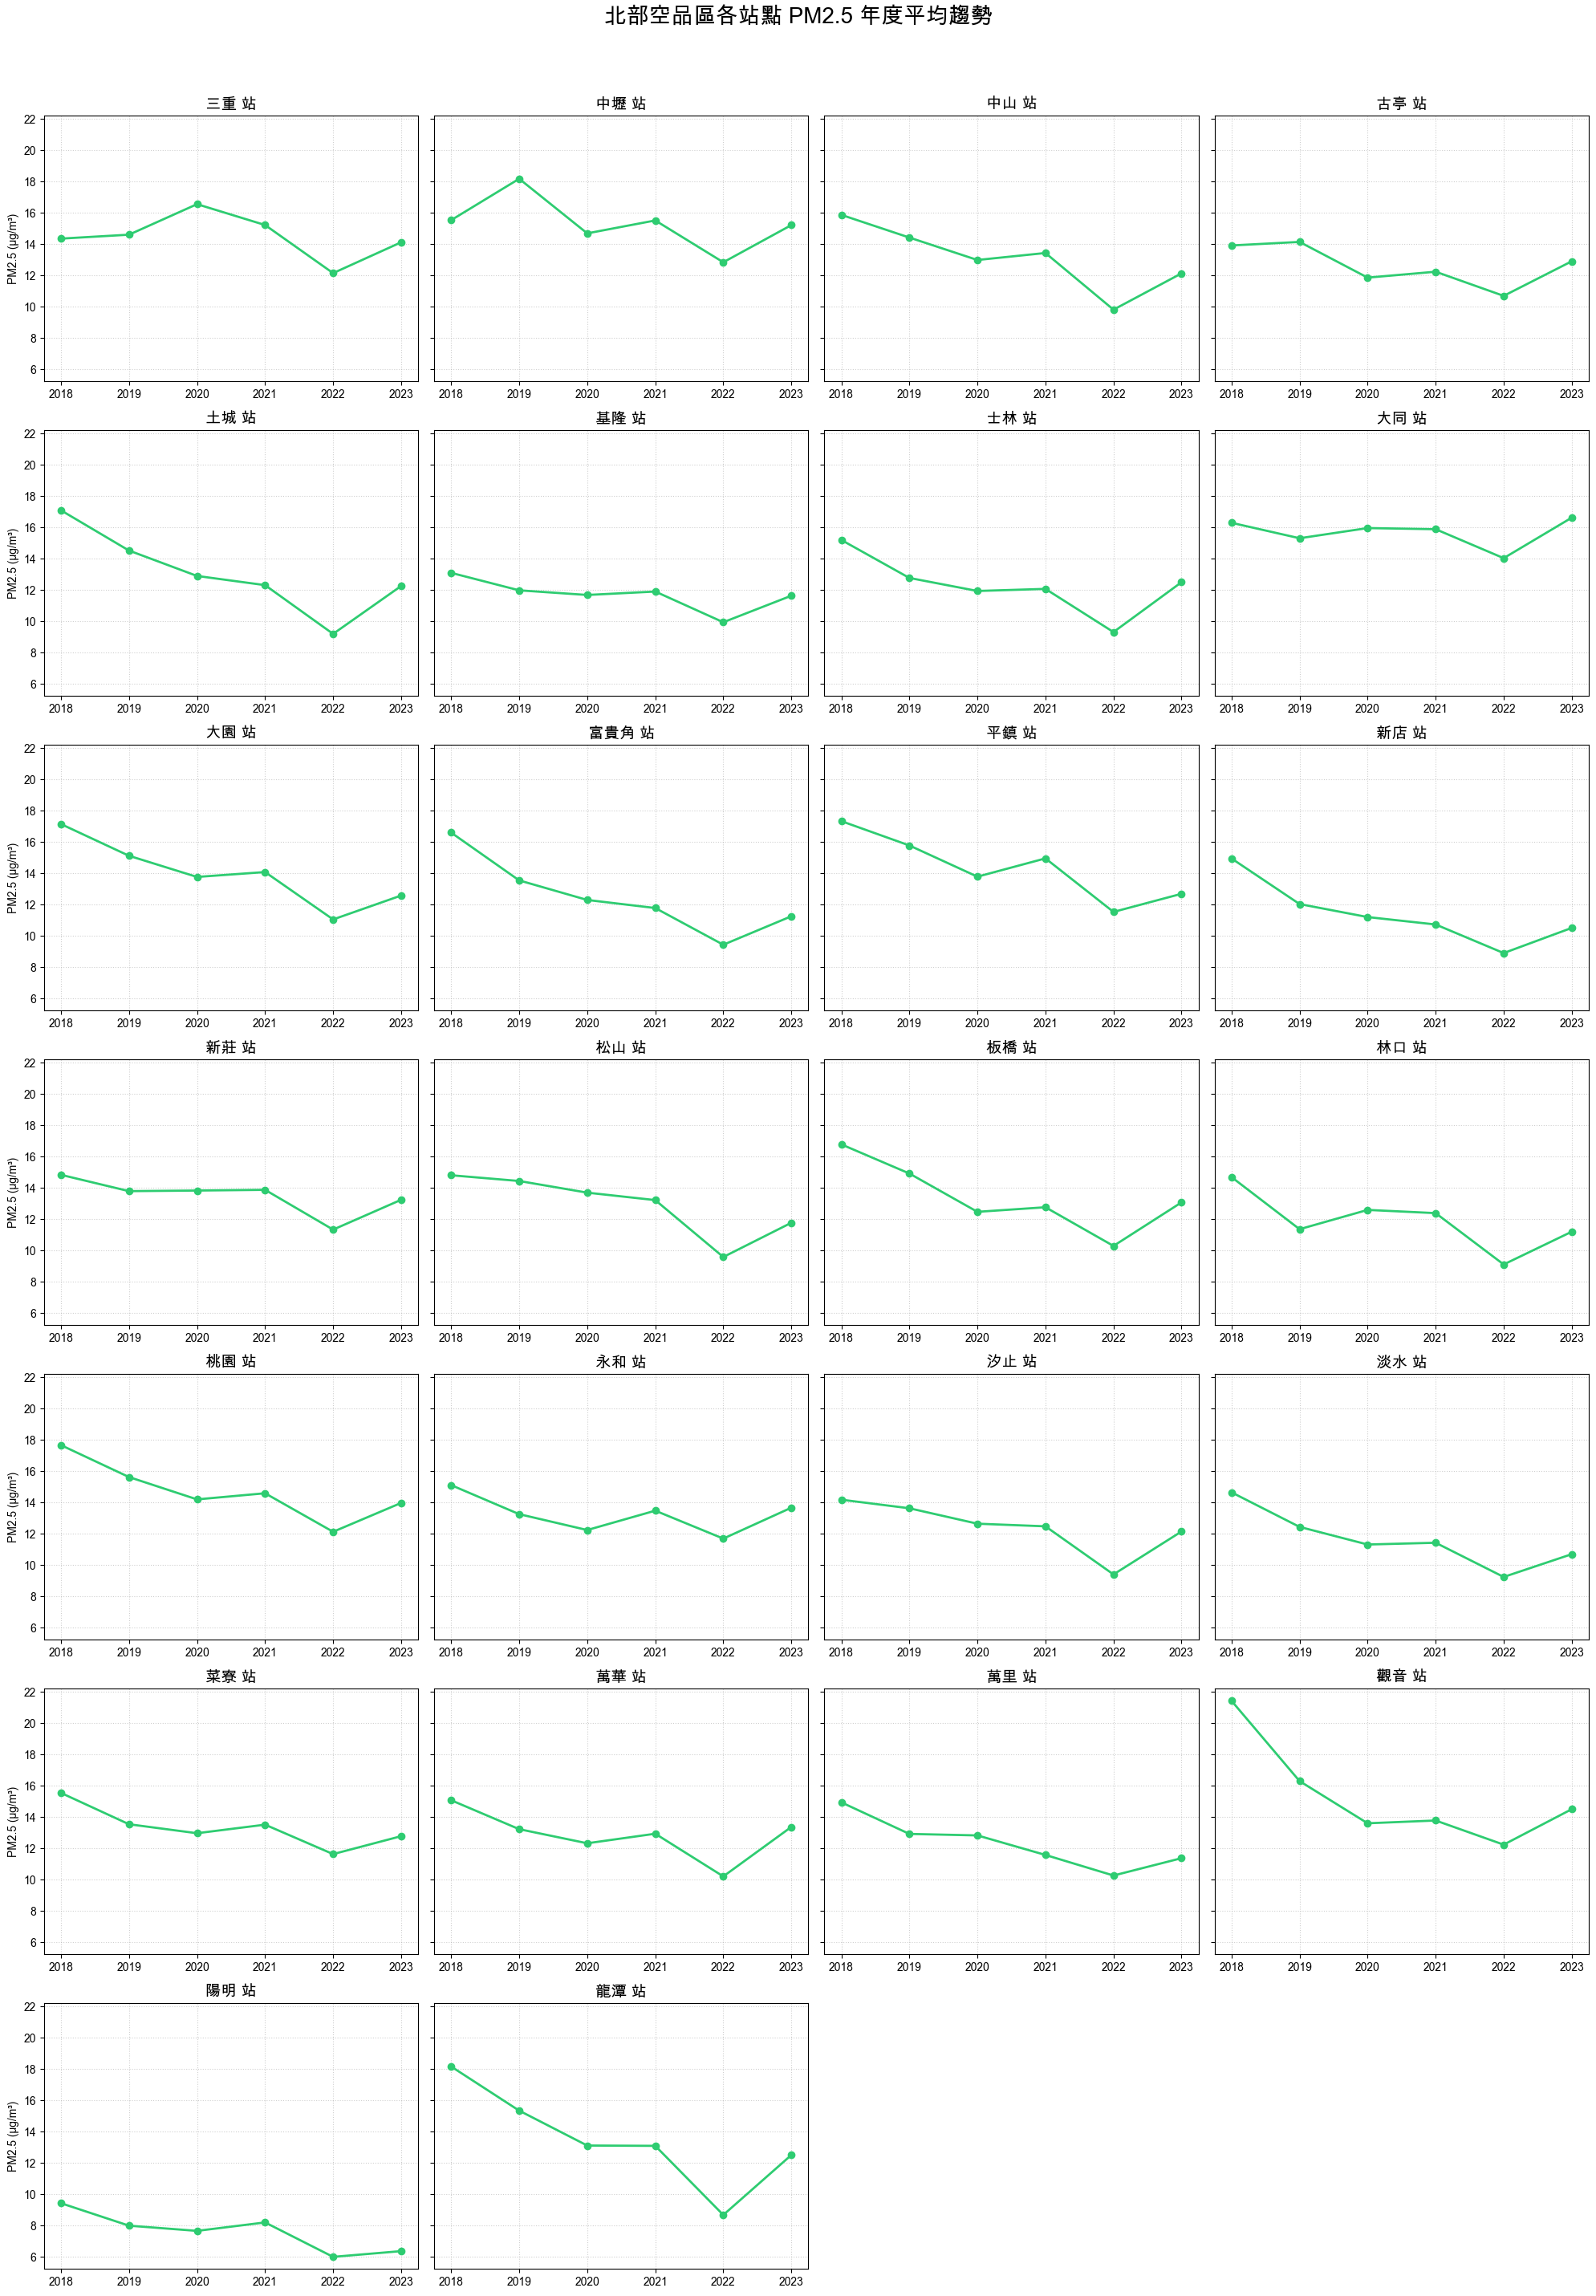

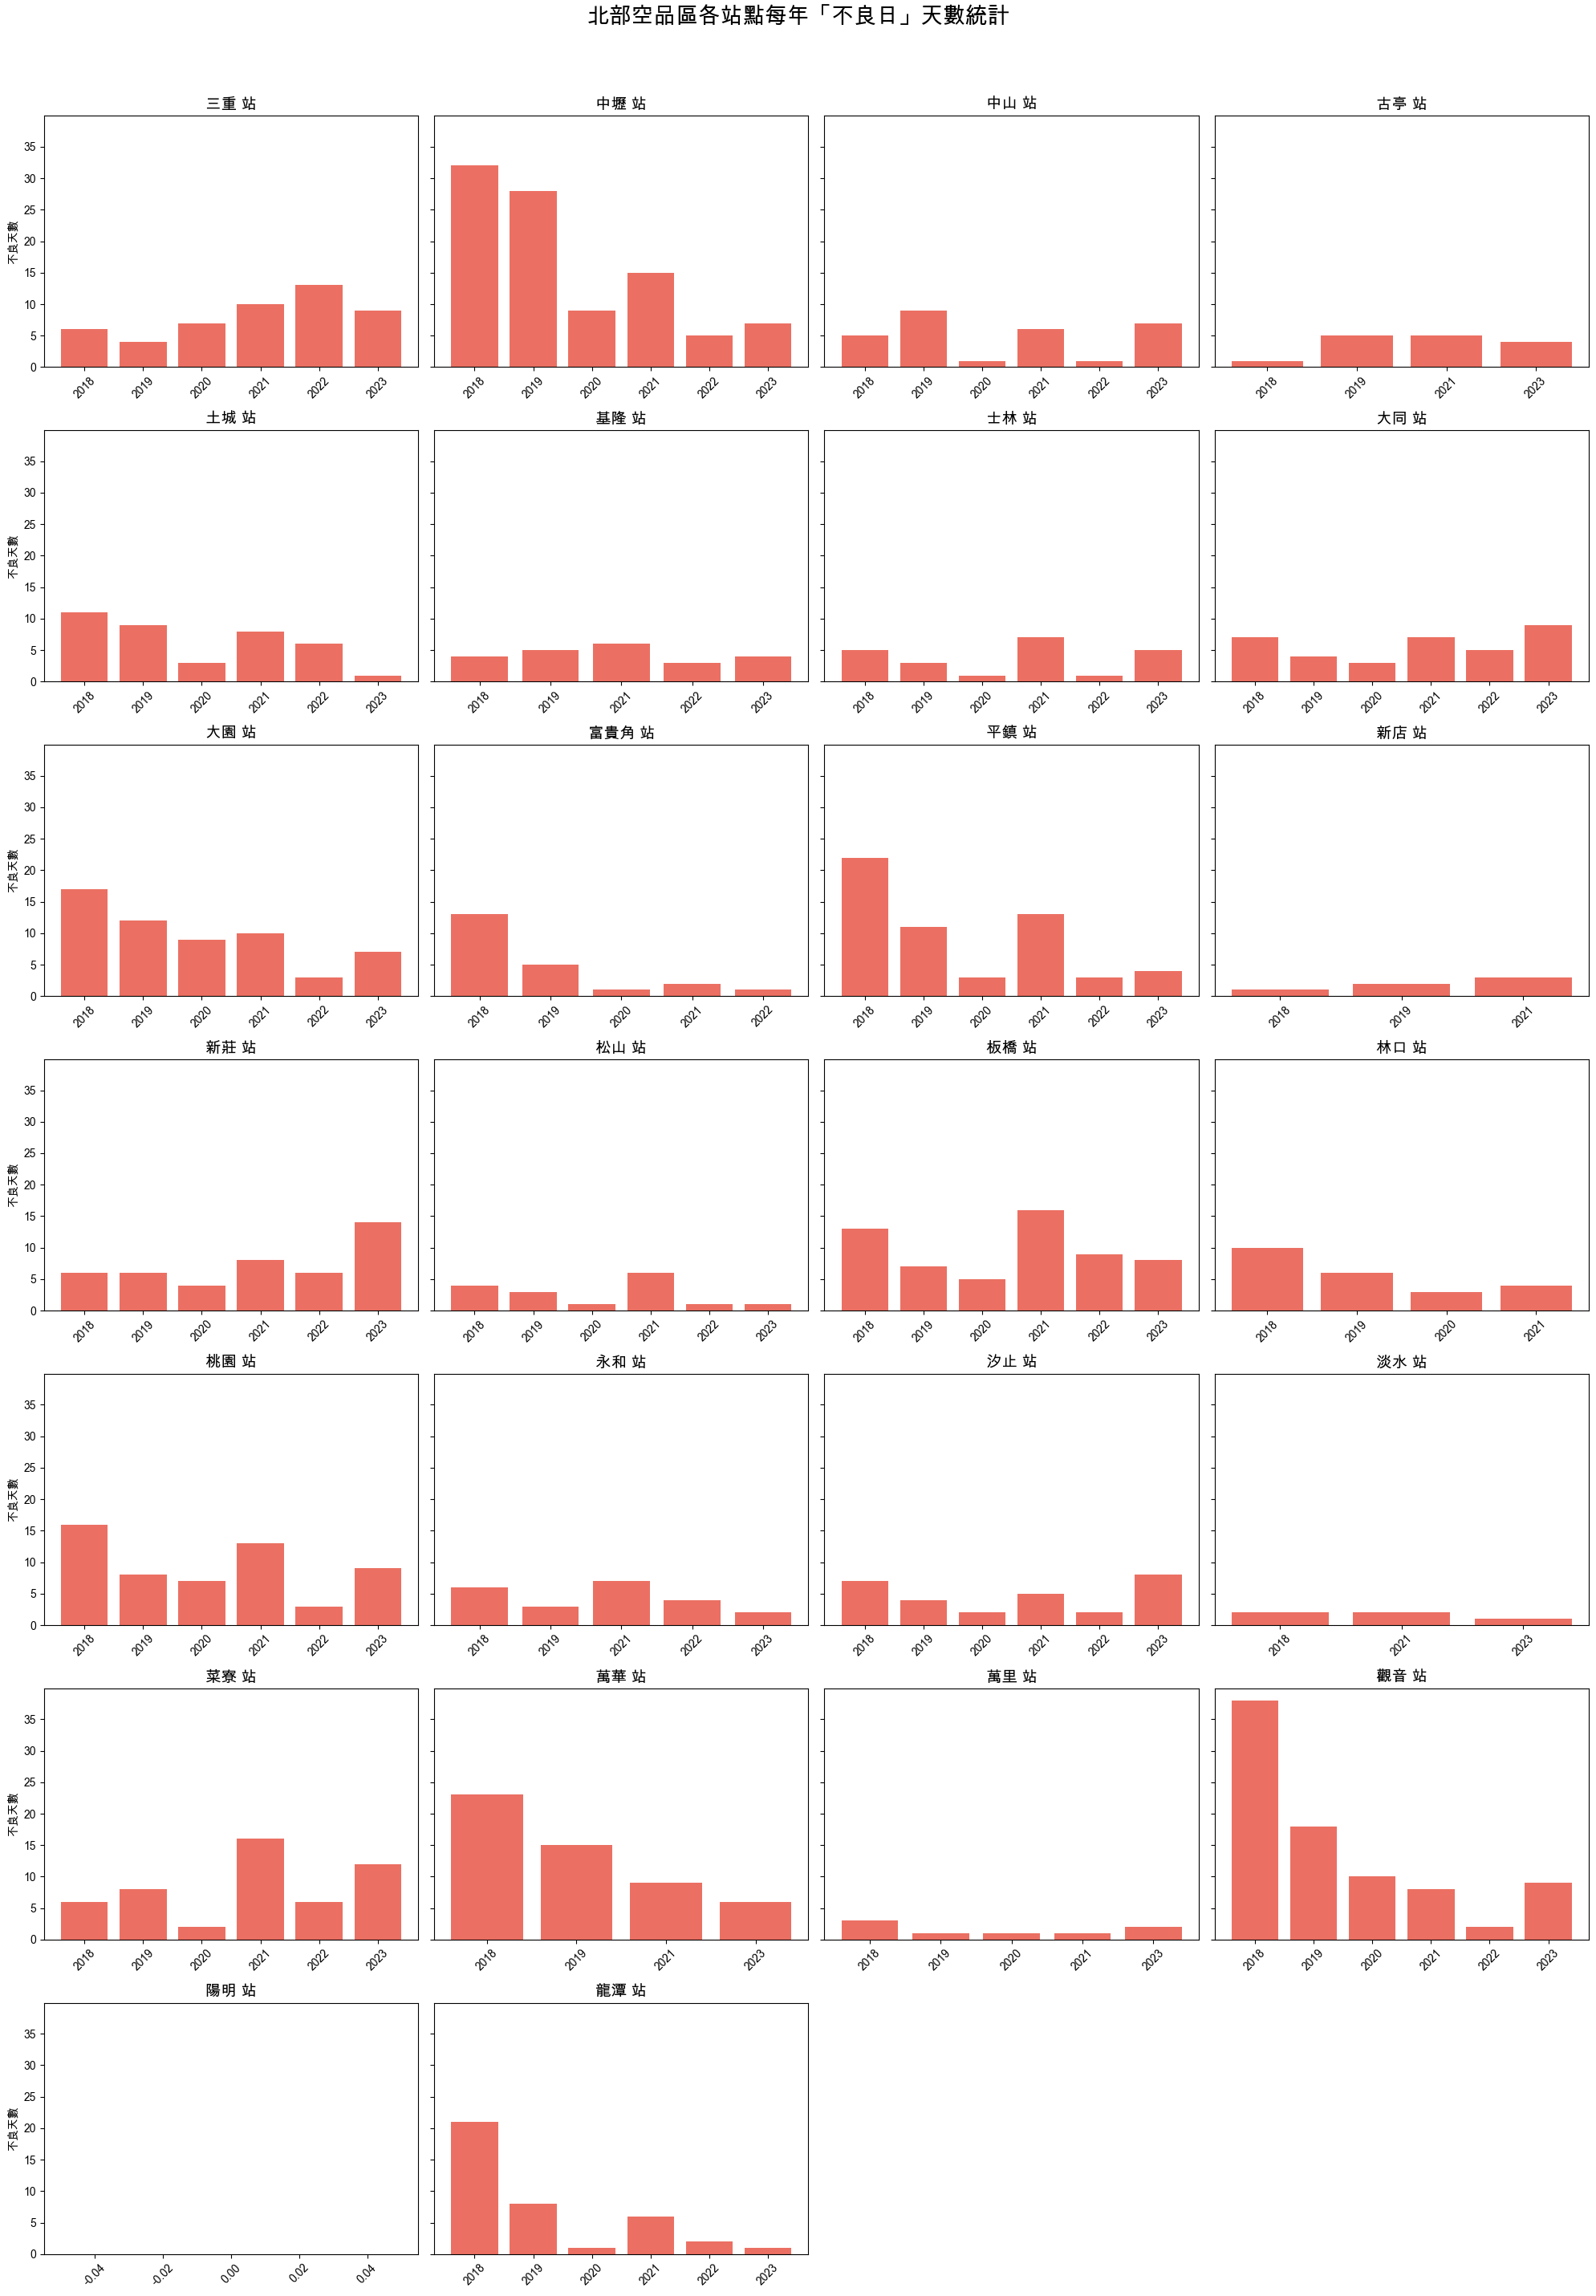

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

def generate_facet_plots(df):
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
    plt.rcParams['axes.unicode_minus'] = False
    
    # 1. 準備資料與網格設定
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Year'] = df['Timestamp'].dt.year
    stations = sorted(df['Station'].unique())
    n_stations = len(stations)
    cols = 4
    rows = (n_stations // cols) + (1 if n_stations % cols != 0 else 0)

    # --- 第一部分：年度趨勢 (一站一格) ---
    fig1, axes1 = plt.subplots(rows, cols, figsize=(20, rows * 4), sharey=True)
    axes1 = axes1.flatten()
    
    # 先算出平均值，避免在迴圈內做重疊繪圖
    annual_data = df.groupby(['Year', 'Station'])['PM2.5'].mean().reset_index()

    for i, station in enumerate(stations):
        data = annual_data[annual_data['Station'] == station]
        # 重點：必須指定 ax=axes1[i]
        axes1[i].plot(data['Year'], data['PM2.5'], marker='o', color='#2ecc71', linewidth=2)
        axes1[i].set_title(f'{station} 站', fontsize=14)
        axes1[i].grid(True, linestyle=':', alpha=0.6)
        if i % cols == 0: axes1[i].set_ylabel('PM2.5 (μg/m³)')
    
    # 隱藏多餘格子
    for j in range(len(stations), len(axes1)): axes1[j].axis('off')
    fig1.suptitle('北部空品區各站點 PM2.5 年度平均趨勢', fontsize=20, y=1.02)
    fig1.tight_layout()

    # --- 第二部分：年度不良日統計 (一站一格) ---
    fig2, axes2 = plt.subplots(rows, cols, figsize=(20, rows * 4), sharey=True)
    axes2 = axes2.flatten()

    # 算日平均 AQI > 100
    daily_aqi = df.groupby(['Year', 'Station', df['Timestamp'].dt.date])['AQI'].mean().reset_index()
    bad_days_df = daily_aqi[daily_aqi['AQI'] > 100].groupby(['Year', 'Station']).size().reset_index(name='BadDays')

    for i, station in enumerate(stations):
        data = bad_days_df[bad_days_df['Station'] == station]
        # 重點：使用 axes2[i].bar 而不是 plt.bar
        axes2[i].bar(data['Year'].astype(str), data['BadDays'], color='#e74c3c', alpha=0.8)
        axes2[i].set_title(f'{station} 站', fontsize=14)
        if i % cols == 0: axes2[i].set_ylabel('不良天數')
        axes2[i].tick_params(axis='x', rotation=45)
    
    for j in range(len(stations), len(axes2)): axes2[j].axis('off')
    fig2.suptitle('北部空品區各站點每年「不良日」天數統計', fontsize=20, y=1.02)
    fig2.tight_layout()
    
    plt.show()

# 執行
generate_facet_plots(df)

/var/folders/17/vsmmd5dx5pv74fwy86w422940000gn/T/ipykernel_24875/18905681.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='PM2.5', data=df, palette='viridis', showfliers=False)


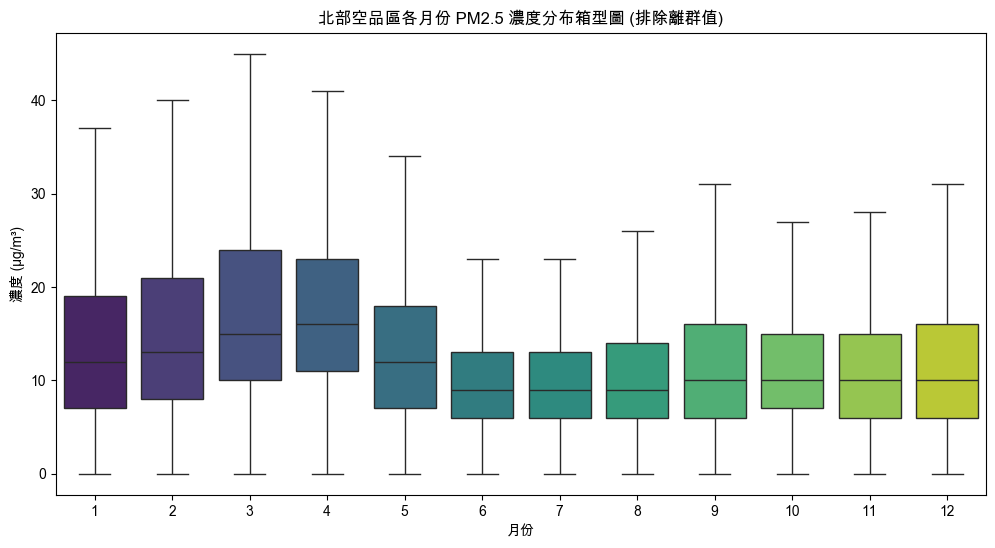

/var/folders/17/vsmmd5dx5pv74fwy86w422940000gn/T/ipykernel_24875/18905681.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='PM2.5', data=df, palette='coolwarm', showfliers=False)


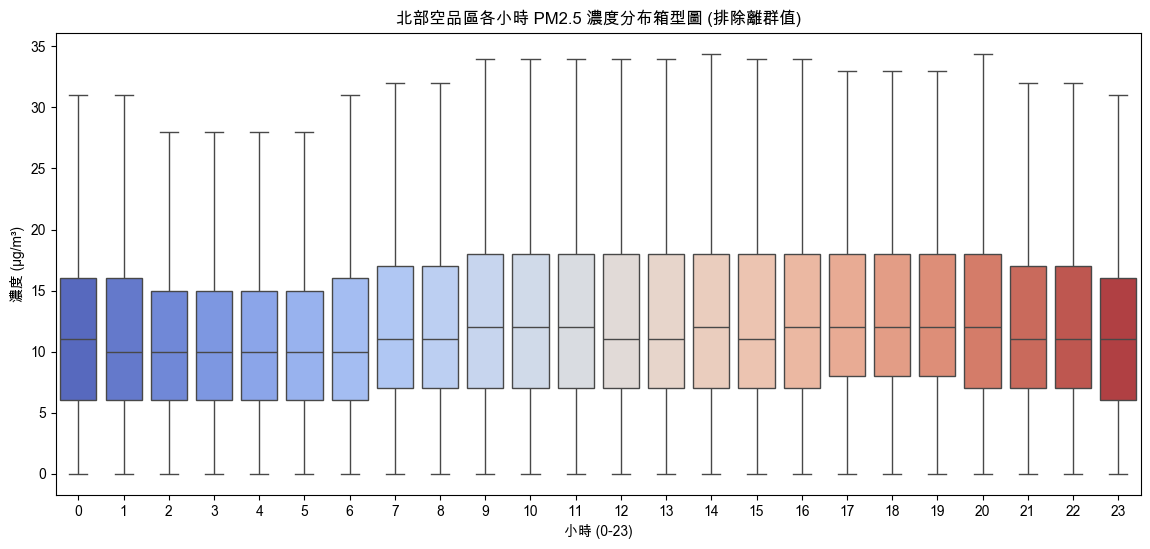

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def generate_advanced_plots(df):
    # 基礎設定
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac 字體
    plt.rcParams['axes.unicode_minus'] = False
    
    # 預處理時間欄位
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Year'] = df['Timestamp'].dt.year
    df['Month'] = df['Timestamp'].dt.month
    df['Hour'] = df['Timestamp'].dt.hour

    # --- 第三張圖：北部空品區各月份的污染物濃度箱型圖 ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(x='Month', y='PM2.5', data=df, palette='viridis', showfliers=False)
    plt.title('北部空品區各月份 PM2.5 濃度分布箱型圖 (排除離群值)')
    plt.xlabel('月份')
    plt.ylabel('濃度 (μg/m³)')
    plt.show()

    # --- 第四張圖：北部空品區各小時的污染物濃度箱型圖 ---
    plt.figure(figsize=(14, 6))
    sns.boxplot(x='Hour', y='PM2.5', data=df, palette='coolwarm', showfliers=False)
    plt.title('北部空品區各小時 PM2.5 濃度分布箱型圖 (排除離群值)')
    plt.xlabel('小時 (0-23)')
    plt.ylabel('濃度 (μg/m³)')
    plt.show()

# 執行繪圖
generate_advanced_plots(df)